In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report

In [3]:
# PATHS
train_dir = "/content/drive/MyDrive/Ai Week 5/FruitinAmazon/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/Ai Week 5/FruitinAmazon/FruitinAmazon/test"

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



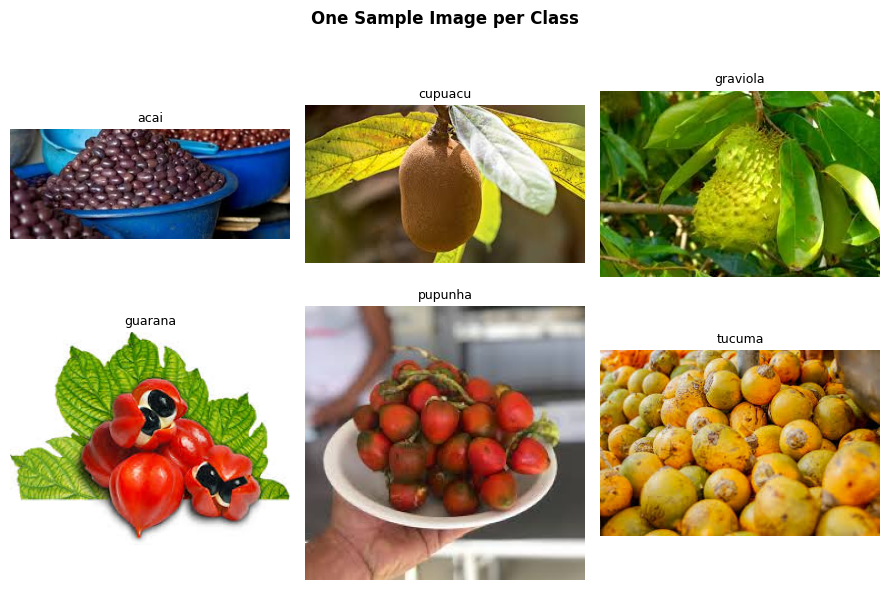

Observation: Images vary in size, background, and lighting across classes.



In [4]:
# TASK 1 — Data Understanding and Visualization
def visualize_classes(train_dir: str) -> None:
    """Display one random image per class in a 2-row grid."""
    class_dirs = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    print(f"Classes found: {class_dirs}\n")

    images, titles = [], []
    for cls in class_dirs:
        cls_path = os.path.join(train_dir, cls)
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if files:
            img_path = os.path.join(cls_path, random.choice(files))
            images.append(Image.open(img_path))
            titles.append(cls)

    n = len(images)
    cols = (n + 1) // 2          # spread across 2 rows
    fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 6))
    axes = axes.flatten()

    for i, (img, title) in enumerate(zip(images, titles)):
        axes[i].imshow(img)
        axes[i].set_title(title, fontsize=9)
        axes[i].axis("off")

    # hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("One Sample Image per Class", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("Observation: Images vary in size, background, and lighting across classes.\n")

visualize_classes(train_dir)

1b. Check for Corrupted Images**

In [5]:
def remove_corrupted_images(train_dir: str) -> None:
    """Scan train directory; remove and report corrupted images."""
    corrupted = []
    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            img_path = os.path.join(cls_path, fname)
            try:
                img = Image.open(img_path)
                img.verify()          # lightweight header check
            except (IOError, SyntaxError):
                corrupted.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

    if not corrupted:
        print("No corrupted images found.")

remove_corrupted_images(train_dir)


No corrupted images found.


TASK 2 — Loading & Preprocessing with **Keras**

In [7]:
IMG_HEIGHT      = 128
IMG_WIDTH       = 128
BATCH_SIZE      = 32
VALIDATION_SPLIT = 0.2

rescale = tf.keras.layers.Rescaling(1.0 / 255)  # normalise [0,255] → [0,1]

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=123,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=123,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}  →  {class_names}")

# Apply normalisation
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))

# Load test set (no split needed — all images used)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123,
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Number of classes: 6  →  ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 30 files belonging to 6 classes.


TASK 3 — Build the CNN

In [8]:
model = keras.Sequential([
    # Input shape
    keras.layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    #  Convolutional Block 1
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1,
                        padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Block 2
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1,
                        padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    #  Fully Connected Head
    keras.layers.Flatten(),
    keras.layers.Dense(64,  activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(num_classes, activation="softmax"),  # output layer
], name="Fruit_CNN")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Compile & Train

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,          # stop if val_loss doesn't improve for 15 epochs
    restore_best_weights=True,
    verbose=1,
)

# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,        # note: effective batch already set in dataset;
                          # model.fit's batch_size is ignored for tf.data inputs
    callbacks=[checkpoint_cb, early_stop_cb],
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.1343 - loss: 1.7819
Epoch 1: val_accuracy improved from None to 0.38889, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 650ms/step - accuracy: 0.1528 - loss: 1.7757 - val_accuracy: 0.3889 - val_loss: 1.6410
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.2888 - loss: 1.5995
Epoch 2: val_accuracy improved from 0.38889 to 0.83333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 0.3194 - loss: 1.5819 - val_accuracy: 0.8333 - val_loss: 1.1553
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.4178 - loss: 1.4936
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.4722 - loss: 1.4327 - val_accuracy: 0.2778 - val_loss: 1.8506
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.4184 - loss: 1.3814
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.4583 - loss: 1.3048 - val_accuracy: 0.7222 - val_loss: 1.0836
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.7963 - loss: 0.9016
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.7639 - loss: 0.9400 - val_accuracy: 0.8333 - val_loss: 0.7708
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8304 - loss: 0.726


Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.9861 - loss: 0.1950 - val_accuracy: 0.8889 - val_loss: 0.5124
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9300 - loss: 0.2220
Epoch 10: val_accuracy improved from 0.88889 to 0.94444, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 0.9306 - loss: 0.2070 - val_accuracy: 0.9444 - val_loss: 0.2354
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9902 - loss: 0.1110
Epoch 11: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 0.9861 - loss: 0.0996 - val_accuracy: 0.8333 - val_loss: 0.2955
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9902 - loss: 0.0531
Epoch 12: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step - accuracy: 0.9861 - loss: 0.0571 - val_accuracy: 0.8333 - val_loss: 0.4555
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 1.0000 - loss: 0.0372
Epoch 13: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 0.8889 - val_loss: 0.4796
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 1.0000 - los

Plot training curves

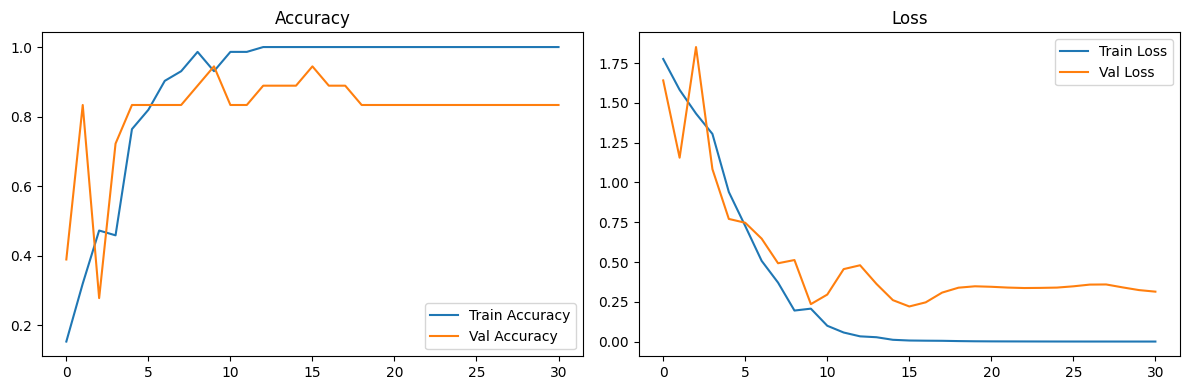

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["accuracy"],     label="Train Accuracy")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Accuracy"); ax1.legend()

ax2.plot(history.history["loss"],     label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Loss"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

TASK 5  Evaluate on Test Set

In [11]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.7000 - loss: 0.9106

Test Loss    : 0.9106
Test Accuracy: 0.7000


TASK 6 — Save and Reload the Model

In [12]:
model.save("fruit_cnn_final.h5")
print("\nModel saved to  fruit_cnn_final.h5")

loaded_model = keras.models.load_model("fruit_cnn_final.h5")
print("Model loaded successfully.")

# Re-evaluate with the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded-model Test Loss    : {loaded_loss:.4f}")
print(f"Loaded-model Test Accuracy: {loaded_acc:.4f}")


Model saved to  fruit_cnn_final.h5
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step - accuracy: 0.7000 - loss: 0.9106

Loaded-model Test Loss    : 0.9106
Loaded-model Test Accuracy: 0.7000


TASK 7 — Predictions & Classification Report


Classification Report:
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.67      0.80      0.73         5
    graviola       0.71      1.00      0.83         5
     guarana       0.67      0.40      0.50         5
     pupunha       0.67      0.80      0.73         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.68        30
weighted avg       0.73      0.70      0.68        30



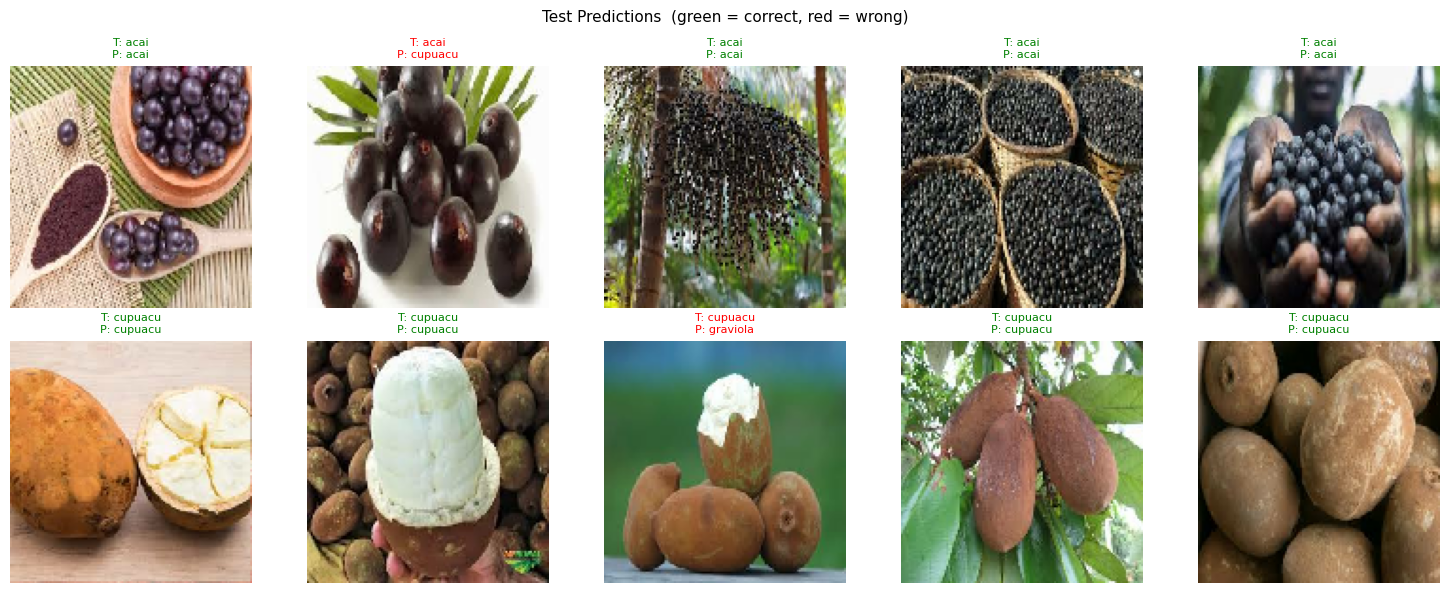

In [13]:
# Collect all true labels and predicted probabilities from the test set
y_true, y_pred_probs = [], []
for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(np.array(y_pred_probs), axis=1)   # probabilities → class index

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Visualise a few test predictions ──────────────────────────
sample_images, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images, verbose=0), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i].numpy())
    true_cls = class_names[sample_labels[i]]
    pred_cls = class_names[sample_preds[i]]
    color = "green" if true_cls == pred_cls else "red"
    ax.set_title(f"T: {true_cls}\nP: {pred_cls}", color=color, fontsize=8)
    ax.axis("off")

plt.suptitle("Test Predictions  (green = correct, red = wrong)", fontsize=11)
plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()